<a href="https://colab.research.google.com/github/rosacarla/inovacao-2ds/blob/main/Revis%C3%A3o4_Aprendizado_de_M%C3%A1quina_Profundo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚀 **Desafio Prático: Aprendizado de Máquina Profundo**  
Nesta revisão, você atuará como desenvolvedor de IA.  
Para começar, <font color="red"><b>salve uma cópia deste notebook no seu Drive.</b></font>   
<br>



⚠️ USE A SUA CÓPIA DO ARQUIVO PARA PREENCHER E ENTREGAR A TAREFA!   
⚠️ LEIA AS INSTRUÇÕES DE CADA CÉLULA E FAÇA TUDO NA ORDEM QUE ESTÁ!   
<BR>   


Complete os blocos de código como é indicado nos comentários para resolver um problema real usando um algoritmo de aprendizado de máquina profundo, denominado **Rede Neural Multicamadas (MLP - Multilayer Perceptron)**. Esta arquitetura clássica de Deep Learning é facilmente reconhecida no código pelo uso de duas camadas fundamentais:
* **`layers.Flatten`**: Que atua na entrada, "achatando" a imagem quadrada de pixels em uma linha reta.
* **`layers.Dense`**: Que forma as camadas de neurônios totalmente conectados para processar as informações e prever a probabilidade do resultado correto.  
<BR>

### **Deep Learning (Reconhecimento de Dígitos)**

<p align="justify">
Neste desafio, usaremos <i>Deep Learning</i> para criar uma rede neural que imita a visão humana. Utilizaremos o dataset MNIST, um conjunto de 70.000 imagens de dígitos manuscritos (0 a 9) que já vem integrado à biblioteca <i>Keras/TensorFlow</i>. A IA busca os pixels diretamente da nuvem, sem necessidade de download manual. A máquina processará esses pontos de cor em camadas digitais para aprender a reconhecer padrões como curvas e retas.</p>  


Exemplos do que a IA vai aprender:


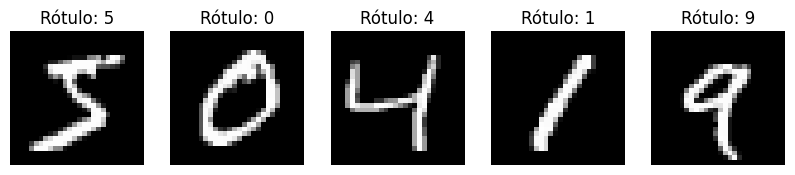

In [2]:
# CLIQUE NO BOTÃO PLAY PARA EXECUTAR A CÉLULA
# Instala e importa as bibliotecas necessárias do Python
import tensorflow as tf # motor principal do Google para criar e treinar redes neurais profundas
from tensorflow.keras import layers, models # Ferramentas para desenhar a arquitetura e empilhar as camadas da rede
import matplotlib.pyplot as plt  # gera gráficos e exibir as imagens dos dados na tela
import numpy as np # biblioteca matemática para manipular matrizes e pixels de imagens em alta velocidade

# 1. CARREGA OS DADOS
# Baixa o banco de dados MNIST: x contém imagens dos números e y contém respostas corretas (rótulos).
# Dados são divididos em 2 partes: um grupo para Treino (estudo) e outro para Teste (exame final).
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# CONFIGURA A VISUALIZAÇÃO DE AMOSTRAS DAS IMAGENS USADAS PARA TREINO DA IA
print("Exemplos do que a IA vai aprender:")
# Cria uma janela de visualização esticada para caber as imagens lado a lado
plt.figure(figsize=(10,2))
# Laço de repetição (for) para desenhar as 5 primeiras imagens na tela
for i in range(5):
    # Divide o painel em 1 linha e 5 colunas, selecionando o espaço onde a imagem atual vai entrar
    plt.subplot(1, 5, i+1)
    # Plota a imagem do número correspondente em tons de cinza (gray)
    plt.imshow(x_train[i], cmap='gray')
    # Adiciona título com a resposta correta (rótulo) para mostrar o que a IA devia responder
    plt.title(f"Rótulo: {y_train[i]}")
    # Esconde as réguas com coordenadas (eixos X e Y) para deixar os desenhos limpos
    plt.axis('off')
# Exibe o painel visual completo na tela do Google Colab
plt.show()

In [3]:
# 2. Normalização (Escalar os pixels de 0-255 para 0-1)
# Simplifica as imagens: transforma a cor de cada pixel (0 a 255) em um número entre 0 e 1.
# Isso faz a Rede Neural processar as imagens e aprender muito mais rápido.
x_train, x_test = x_train / 255.0, x_test / 255.0

# 3. CONSTRÓI A ARQUITETURA DA REDE NEURAL (O CÉREBRO ARTIFICIAL)
# Cria um modelo "Sequential" ou uma esteira onde as camadas de neurônios são empilhadas em ordem.
modelo = models.Sequential([
    # Camada de Entrada: Pega a imagem quadrada (28x28 pixels) e "achata" transformando-a em uma linha reta de 784 pontos.
    layers.Flatten(input_shape=(28, 28)),
    # Camada Intermediária: Possui 128 neurônios que vão cruzar as informações dos pixels para encontrar os padrões do desenho.
    layers.Dense(128, activation='relu'),
    # Camada de Saída: Possui 10 neurônios (um para cada número de 0 a 9). Ela dá a previsão final em formato de probabilidade.
    layers.Dense(10, activation='softmax')
])

# CONFIGURA O SISTEMA DE APRENDIZADO
# Define o otimizador ("treinador" que ajusta os neurônios) e a métrica para medir a precisão (accuracy) dos acertos.
modelo.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# REALIZA O TREINAMENTO
# IA lê e analisa todo o banco de dados de imagens exatamente 2 vezes (epochs) para aprender a prever os números.
modelo.fit(x_train, y_train, epochs=2)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9277 - loss: 0.2532
Epoch 2/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9668 - loss: 0.1113


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Resultados da IA no 'Exame Final':


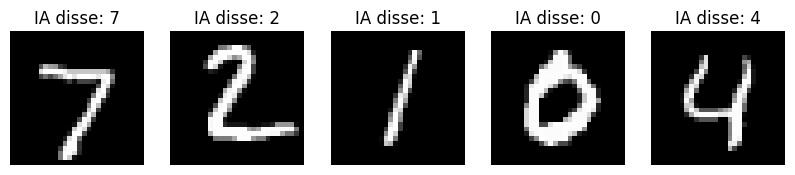

In [4]:
# TESTE PRÁTICO COM IMAGENS REAIS
# IA gera previsões (calcula chances/probabilidades) para as imagens de teste
previsoes = modelo.predict(x_test)

print("\nResultados da IA no 'Exame Final':")
# Configura o tamanho da janela do gráfico para exibir 5 imagens lado a lado
plt.figure(figsize=(10,2))

for i in range(5):
    # Organiza as imagens na tela em 1 linha e 5 colunas
    plt.subplot(1, 5, i+1)
    # Exibe a imagem atual em tons de cinza na tela
    plt.imshow(x_test[i], cmap='gray')
    # np.argmax: IA gera 10 probabilidades. Essa função descobre qual delas é a maior
    # e devolve o número exato (de 0 a 9) em que a IA tem mais certeza.
    resultado = np.argmax(previsoes[i])
    # Adiciona o título acima da imagem mostrando a resposta final que a IA calculou
    plt.title(f"IA disse: {resultado}")
    # Remove as linhas e números dos eixos do gráfico para a imagem ficar limpa
    plt.axis('off')
# Mostra o painel visual completo na tela
plt.show()

🎉 Parabéns por chegar até aqui!  
- Salve o seu arquivo clicando no menu "Arquivo/Salvar e fixar revisão".  
- Desbloqueie o link pelo botão azul "Compartilhar", na opção "Acesso geral/Qualquer pessoa com o link".
- Copie o link desbloqueado deste notebook como resposta do exercício no Classroom.  
- Clique em "Arquivo/Salvar uma cópia no Github", selecione o repositorio <b>inovacao-2ds</b> e OK.